# Foodpanda Customer Churn Prediction
Step-by-step notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Update the file path if needed
df = pd.read_csv("E:\\Deep Learning\\Foodpanda\\dataset\\Foodpanda.csv")

date_cols = ["signup_date", "order_date", "last_order_date", "rating_date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

text_cols = ["customer_id", "gender", "age", "city", "order_id",
             "restaurant_name", "dish_name", "category",
             "payment_method", "churned", "delivery_status"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df["rating_status"] = np.where(df["rating"].isna(), "Not Rated", "Rated")
df["order_value"] = df["quantity"] * df["price"]
df = df.rename(columns={"age": "age_group"})

reference_date = df["last_order_date"].max()
df["tenure_days"] = (reference_date - df["signup_date"]).dt.days
df["recency_days"] = (reference_date - df["last_order_date"]).dt.days
df["order_month"] = df["order_date"].dt.month
df["order_year"] = df["order_date"].dt.year
df["order_day"] = df["order_date"].dt.day
df["order_weekday"] = df["order_date"].dt.day_name()

print("Shape:", df.shape)
df.head()

Shape: (6000, 28)


,customer_id,gender,age_group,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,...,rating_date,delivery_status,rating_status,order_value,tenure_days,recency_days,order_month,order_year,order_day,order_weekday
0,C5663,Male,Adult,Peshawar,2024-01-14,O9663,2023-08-23,McDonald's,Burger,Italian,...,2024-10-14,Cancelled,Not Rated,7391.35,585,33,8,2023,23,Wednesday
1,C2831,Male,Adult,Multan,2024-07-07,O6831,2023-08-23,KFC,Burger,Italian,...,2025-08-21,Delayed,Rated,2868.12,410,269,8,2023,23,Wednesday
2,C2851,Other,Senior,Multan,2025-06-20,O6851,2023-08-23,Pizza Hut,Fries,Italian,...,2024-09-19,Delayed,Rated,1765.02,62,103,8,2023,23,Wednesday
3,C1694,Female,Senior,Peshawar,2023-09-05,O5694,2023-08-23,Subway,Pizza,Dessert,...,2025-06-29,Delayed,Rated,925.20,716,28,8,2023,23,Wednesday
4,C4339,Other,Senior,Lahore,2023-12-29,O8339,2023-08-24,KFC,Sandwich,Dessert,...,2025-03-06,Cancelled,Not Rated,1156.69,601,243,8,2023,24,Thursday


In [3]:
churn_df = df.copy()

features = [
    "gender", "age_group", "city", "restaurant_name", "dish_name",
    "category", "quantity", "price", "payment_method",
    "order_frequency", "loyalty_points", "rating",
    "delivery_status", "tenure_days", "recency_days", "order_value"
]
target = "churned"

churn_data = churn_df[features + [target]].copy()
churn_data["rating"] = churn_data["rating"].fillna(churn_data["rating"].median())
churn_data.head()

,gender,age_group,city,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,loyalty_points,rating,delivery_status,tenure_days,recency_days,order_value,churned
0,Male,Adult,Peshawar,McDonald's,Burger,Italian,5,1478.27,Cash,38,238,3.0,Cancelled,585,33,7391.35,Active
1,Male,Adult,Multan,KFC,Burger,Italian,3,956.04,Wallet,24,81,2.0,Delayed,410,269,2868.12,Active
2,Other,Senior,Multan,Pizza Hut,Fries,Italian,2,882.51,Cash,42,82,3.0,Delayed,62,103,1765.02,Inactive
3,Female,Senior,Peshawar,Subway,Pizza,Dessert,4,231.30,Card,27,45,2.0,Delayed,716,28,925.20,Inactive
4,Other,Senior,Lahore,KFC,Sandwich,Dessert,1,1156.69,Cash,35,418,3.0,Cancelled,601,243,1156.69,Inactive


In [4]:
label_encoders = {}
cat_cols = churn_data.select_dtypes(include="object").columns.tolist()
cat_cols.remove(target)

for col in cat_cols:
    le = LabelEncoder()
    churn_data[col] = le.fit_transform(churn_data[col])
    label_encoders[col] = le

target_le = LabelEncoder()
churn_data[target] = target_le.fit_transform(churn_data[target])

X = churn_data.drop(columns=[target])
y = churn_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(4800, 16) (1200, 16)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.4741666666666667
              precision    recall  f1-score   support

           0       0.48      0.53      0.50       603
           1       0.47      0.42      0.44       597

    accuracy                           0.47      1200
   macro avg       0.47      0.47      0.47      1200
weighted avg       0.47      0.47      0.47      1200



In [6]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5275
              precision    recall  f1-score   support

           0       0.53      0.54      0.54       603
           1       0.53      0.51      0.52       597

    accuracy                           0.53      1200
   macro avg       0.53      0.53      0.53      1200
weighted avg       0.53      0.53      0.53      1200



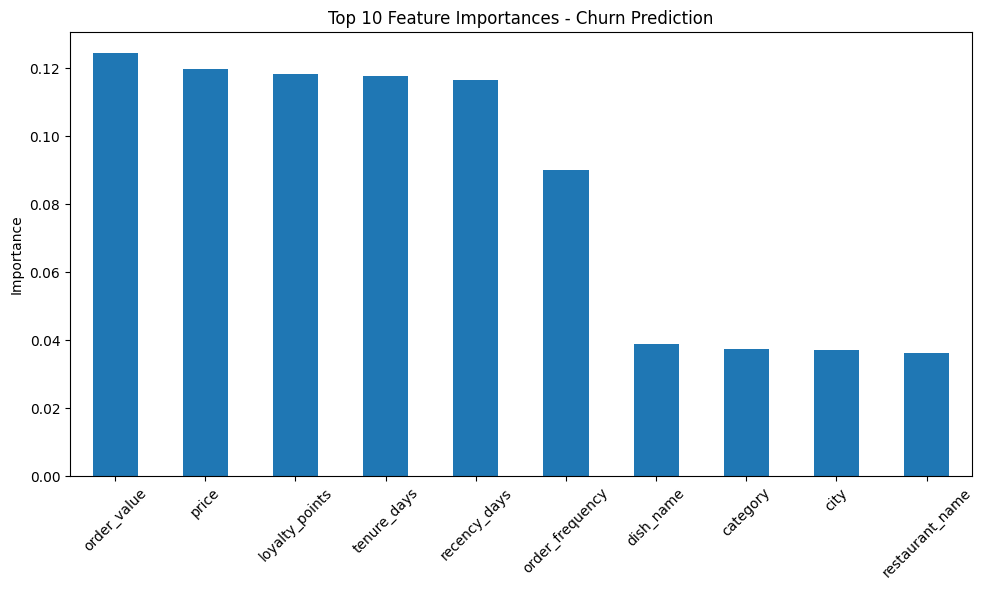

In [7]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances - Churn Prediction")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()